# notebooks imports

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor





# Display options

In [58]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# gather data

In [59]:
california_dataset = fetch_california_housing() # type => sklearn.utils.Bunch



dir(california_dataset) # check available data





['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [60]:



df = pd.DataFrame(data=california_dataset.data,columns=california_dataset.feature_names)


df["PRICE"] = california_dataset.target



# data exploration

In [61]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [62]:
df.describe()


# we see on the data that the median income is the most important feature

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [63]:
df.isnull().sum()



MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# Univariate Analysis

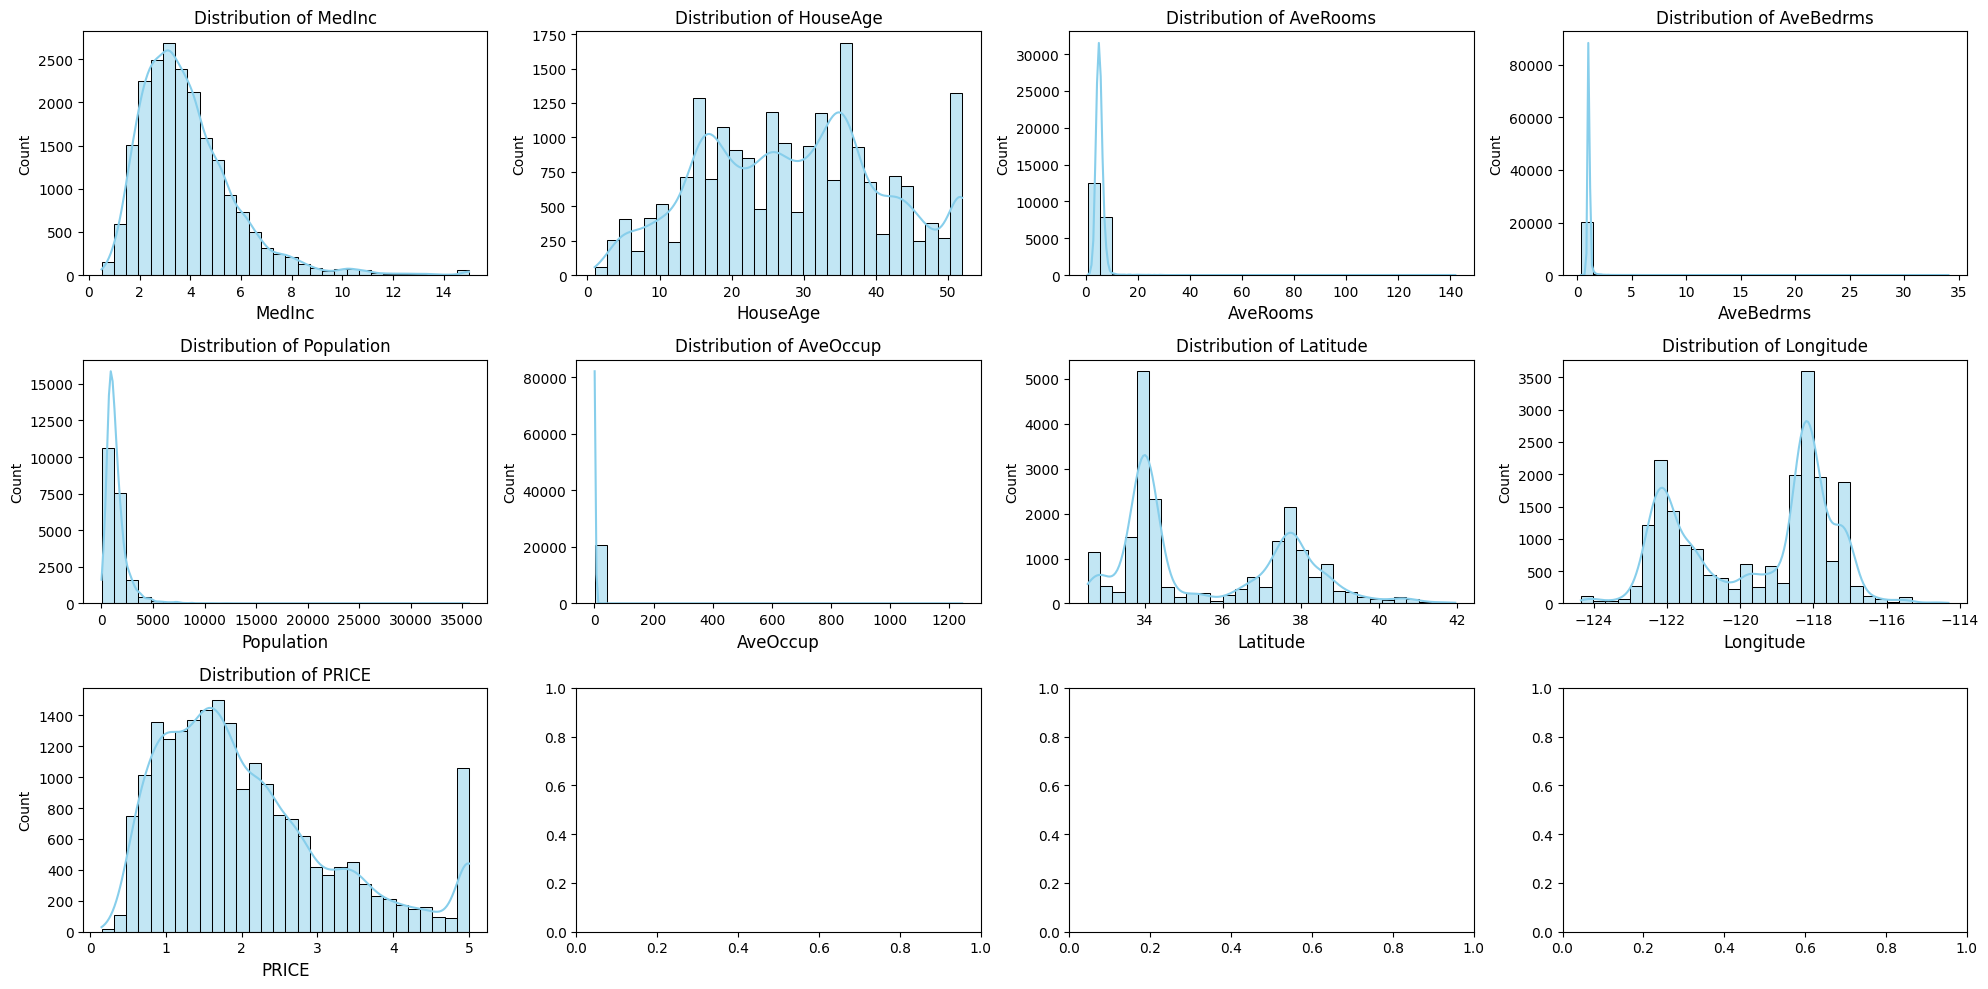

In [65]:
fig,axes = plt.subplots(3,4,figsize=(20,10))

cols = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude',"PRICE"]

axes = axes.flatten() # TODO explore

for i,col in enumerate(cols):
    sns.histplot(df[col],kde=True,ax=axes[i],color='skyblue',edgecolor='black',bins=30)
    axes[i].set_title(f'Distribution of {col}',fontsize= 12)
    axes[i].set_xlabel(f'{col}',fontsize= 12)


plt.tight_layout()
plt.show()

# feature engineering

In [66]:
# chech max values of features



df.AveRooms.max()
df.AveBedrms.max()
df.Population.max()
df.AveOccup.max()


np.float64(1243.3333333333333)

In [67]:
df["log-median-income"] = np.log1p(df["MedInc"])
# 


# IQR 

$Upper Bound=Q3+1.5×IQR$

In [68]:
for i,col in enumerate(['AveRooms', 'AveBedrms', 'Population', 'AveOccup']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    lower_bound = Q1 - 1.5 * (Q3 - Q1)
    upper_bound = Q3 + 1.5 * (Q3 - Q1)

    df = df[(df[col] > lower_bound) & (df[col] < upper_bound)]

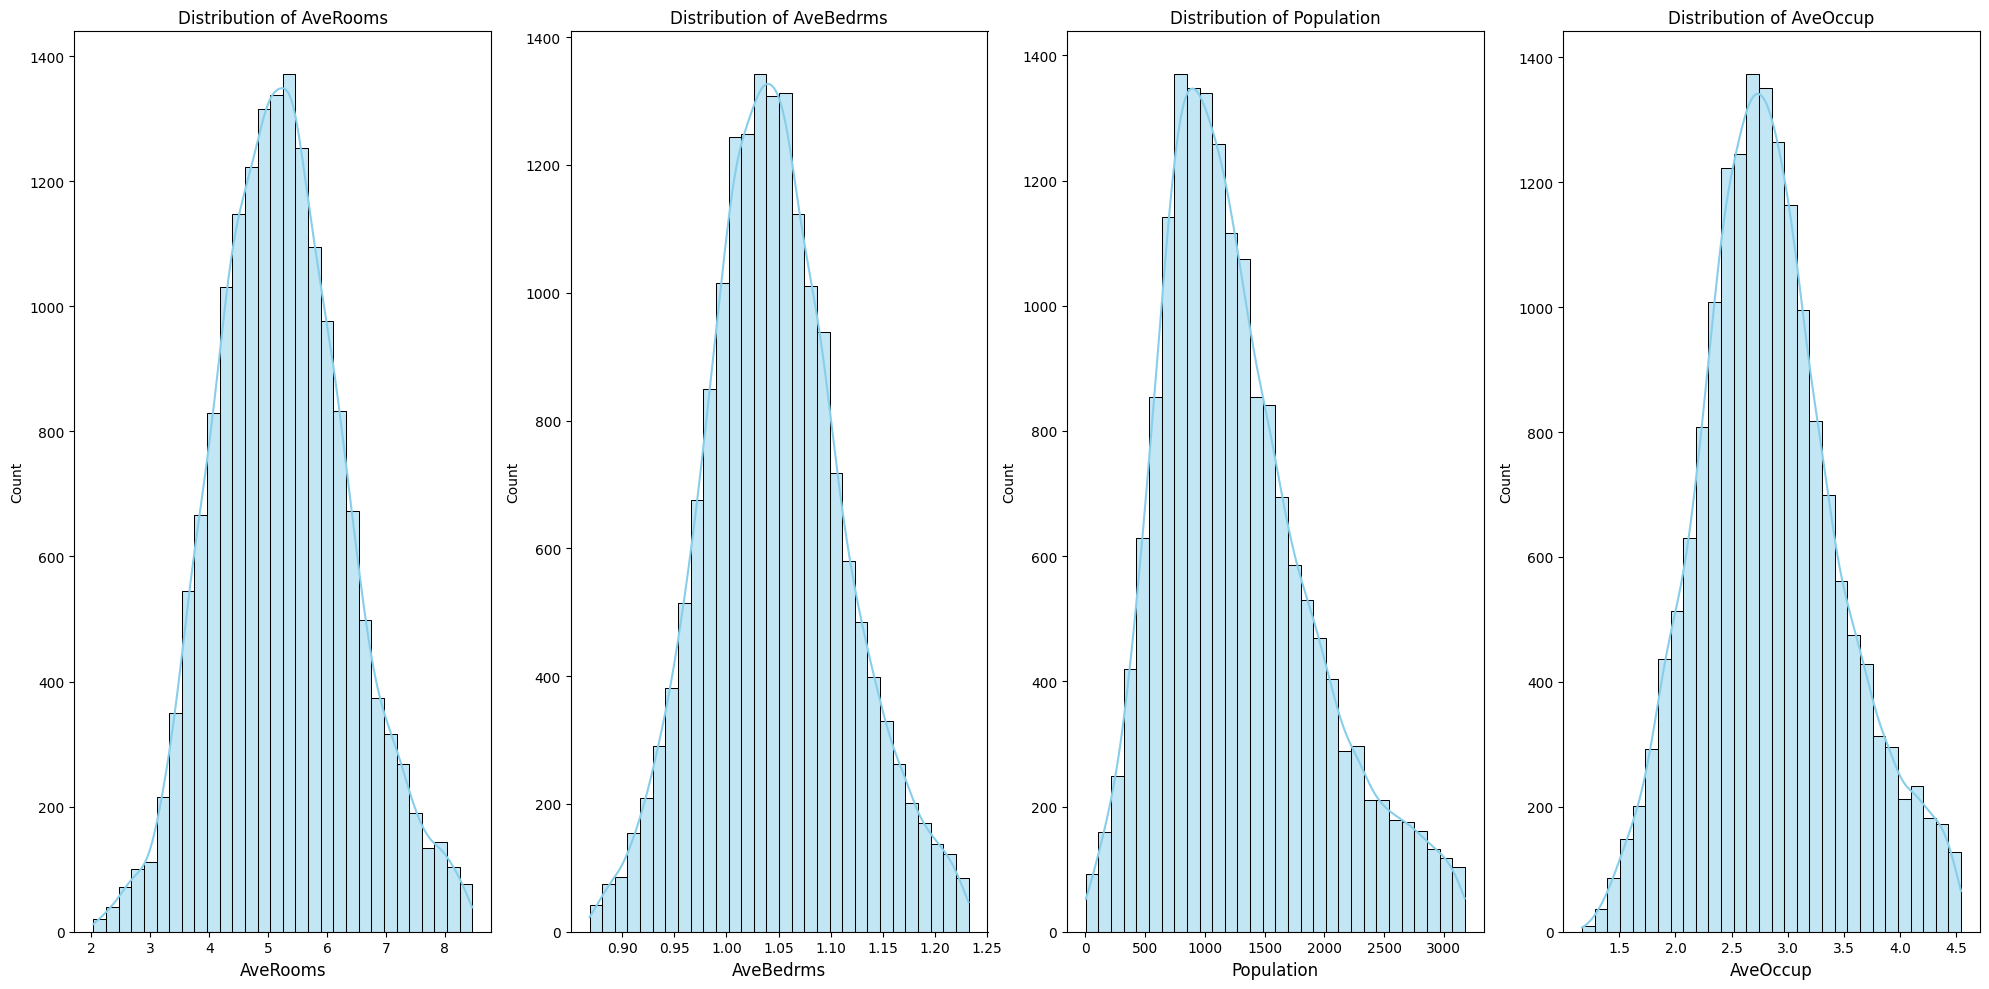

In [69]:

# check problematic features

fig,axes = plt.subplots(1,4,figsize=(20,10))

cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup',]

axes = axes.flatten() # TODO explore

for i,col in enumerate(cols):
    sns.histplot(df[col],kde=True,ax=axes[i],color='skyblue',edgecolor='black',bins=30)
    axes[i].set_title(f'Distribution of {col}',fontsize= 12)
    axes[i].set_xlabel(f'{col}',fontsize= 12)


plt.tight_layout()
plt.show()

## latitude longitude 

In [70]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  


    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2]) # convert to radians

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c





In [71]:
# create to center features


LA_LAT = 34.0522
LA_LON = -118.2437


SF_LAT = 37.7749
SF_LON = -122.4194


SD_LAT = 32.7157
SD_LON = -117.1611

SAC_LAT = 38.5816
SAC_LON = -121.4944



toLA = haversine(df["Latitude"],df["Longitude"],LA_LAT,LA_LON)
toSF = haversine(df["Latitude"],df["Longitude"],SF_LAT,SF_LON)
toSD = haversine(df["Latitude"],df["Longitude"],SD_LAT,SD_LON)
toSAC = haversine(df["Latitude"],df["Longitude"],SAC_LAT,SAC_LON)


df["nearest_to_LA"] = toLA
df["nearest_to_SF"] = toSF
df["nearest_to_SD"] = toSD
df["nearest_to_SAC"] = toSAC

df["nearest_to_city"] = df[["nearest_to_LA", "nearest_to_SF", "nearest_to_SD", "nearest_to_SAC"]].min(axis=1)


df.head()


# create to center features

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE,log-median-income,nearest_to_LA,nearest_to_SF,nearest_to_SD,nearest_to_SAC,nearest_to_city
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.232720,556.531199,20.329542,735.504257,101.066240,20.329542
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.230165,554.281885,19.908065,733.239331,102.254308,19.908065
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.111110,554.612739,17.835390,733.528120,104.214865,17.835390
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,1.893579,555.196283,17.064123,734.097724,104.763122,17.064123
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1.578195,555.196283,17.064123,734.097724,104.763122,17.064123


# bivariate analysis(hypothesis testing)

# Multivariate(correlation matrix)

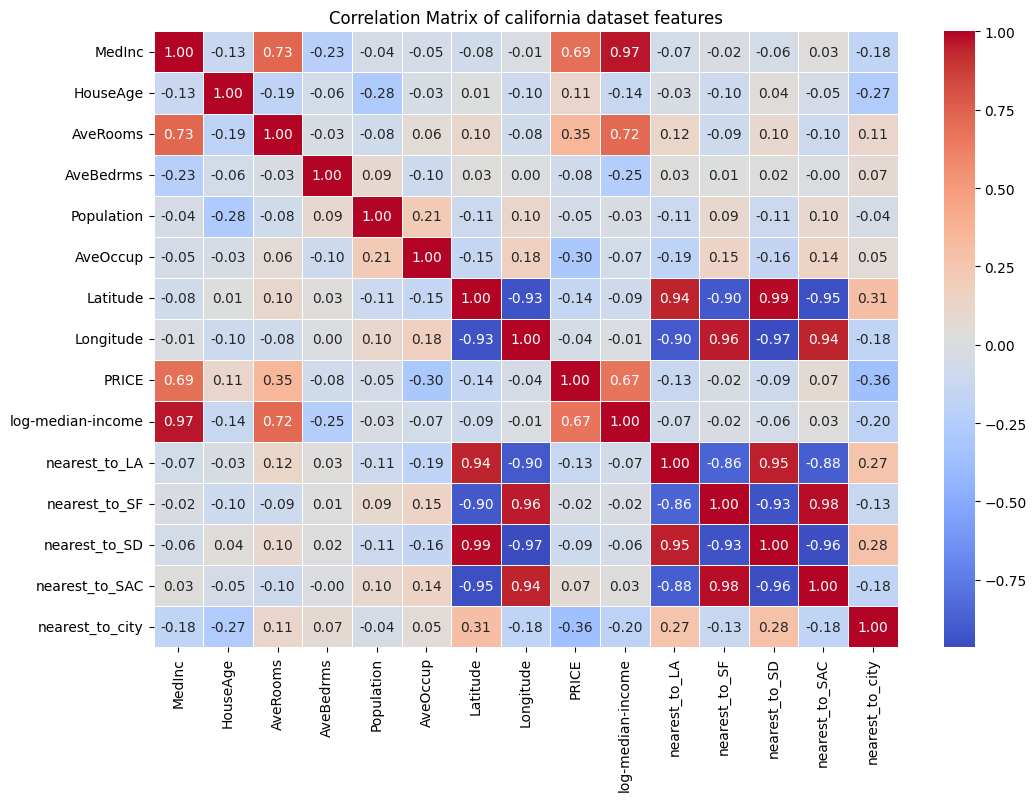

In [72]:
corr_matrix = df.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",linewidths=0.5,fmt=".2f")
plt.title("Correlation Matrix of california dataset features")
plt.show()

In [73]:

# feature engineering
df['Bedroom_Ratio'] = df['AveBedrms'] / df['AveRooms']
df['log-price'] = np.log(df["PRICE"])
df.drop(['PRICE'],axis=1,inplace=True)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,log-median-income,nearest_to_LA,nearest_to_SF,nearest_to_SD,nearest_to_SAC,nearest_to_city,Bedroom_Ratio,log-price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,2.232720,556.531199,20.329542,735.504257,101.066240,20.329542,0.146591,1.509839
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,2.230165,554.281885,19.908065,733.239331,102.254308,19.908065,0.155797,1.276758
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,2.111110,554.612739,17.835390,733.528120,104.214865,17.835390,0.129516,1.258745
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,1.893579,555.196283,17.064123,734.097724,104.763122,17.064123,0.184458,1.227592
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,1.578195,555.196283,17.064123,734.097724,104.763122,17.064123,0.172096,1.230225


# bivariate analysis(correlation testing)

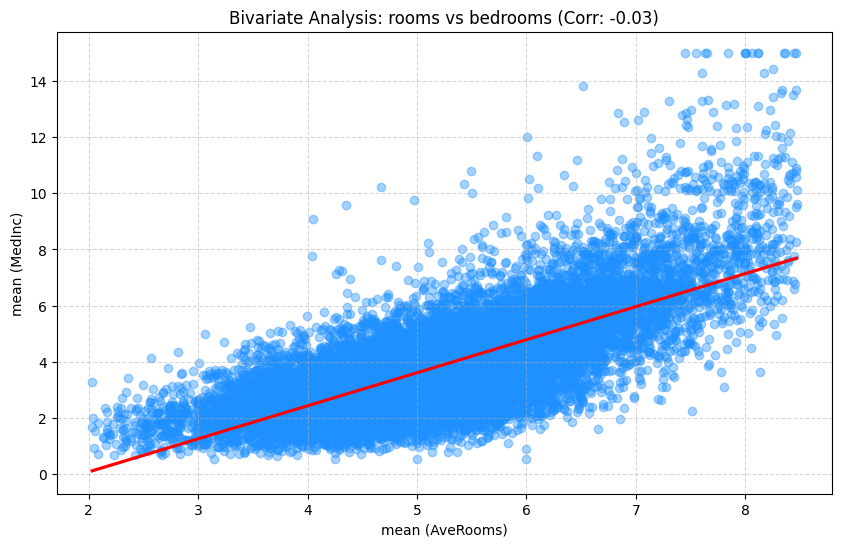

In [74]:
plt.figure(figsize=(10, 6))

params = {
    'data': df,
    'x': 'AveRooms', 
    'y': 'MedInc', 
    'scatter_kws': {'alpha': 0.4, 'color': 'dodgerblue', 'edgecolor': None},
    'line_kws': {'color': 'red'} 
}

sns.regplot(**params)

plt.title(f'Bivariate Analysis: AveRooms vs MedInc (Corr: {df.MedInc.corr(df.AveRooms):.2f})')
plt.xlabel('mean (AveRooms)')
plt.ylabel('mean (MedInc)')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


# Preprocessing Pipeline

In [75]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = ['AveBedrms', 'Population', 'AveOccup', 'Bedroom_Ratio', 'log-median-income']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessors = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

X_transformed = preprocessors.fit_transform(df)
feature_names = preprocessors.get_feature_names_out()
X_ready = pd.DataFrame(X_transformed, columns=feature_names)


# vif


 $(VIF_i = \frac{1}{1 - R_i^2})$

In [76]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def calcute_vif(df):
    vif_data = pd.DataFrame()
    vif_data['feature'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values,i) for i in range(df.shape[1])] 
    return vif_data.sort_values(by="VIF",ascending=False)


vif_results = calcute_vif(X_ready)
vif_results

,feature,VIF
3,num__Bedroom_Ratio,2.027960
4,num__log-median-income,1.981985
0,num__AveBedrms,1.112125
2,num__AveOccup,1.104933
1,num__Population,1.083304


# BIC
(Bayesian Information Criterion)

In [77]:
y = df['log-price'].reset_index(drop=True)


X_incl_const = sm.add_constant(X_ready) 

model_stats = sm.OLS(y,X_incl_const)

results = model_stats.fit()

print(results.summary())
print("R-squared:", results.rsquared)
print("R-squared Adjusted:", results.rsquared_adj)
print("biс is :", results.bic)



                            OLS Regression Results                            
Dep. Variable:              log-price   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     5255.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        23:25:38   Log-Likelihood:                -6626.8
No. Observations:               17306   AIC:                         1.327e+04
Df Residuals:                   17300   BIC:                         1.331e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

# Train dataset


In [78]:
from sklearn.model_selection import train_test_split, cross_val_score,  GridSearchCV

X = df.drop('log-price',axis=1)
y = df['log-price']



X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



# check data shape

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(13844, 15) (13844,)
(1731, 15) (1731,)
(1731, 15) (1731,)


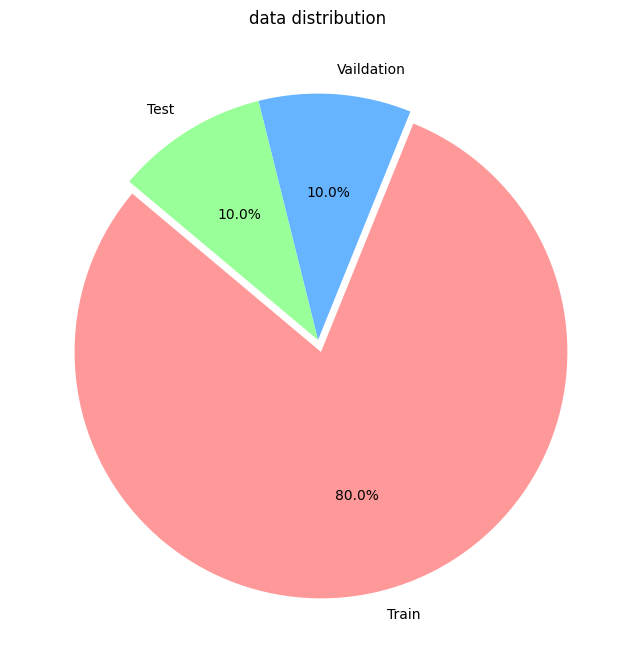

In [79]:
# visualize data distribution


labels  = ['Train','Vaildation','Test']
sizes = [round(len(X_train)),round(len(X_val)),round(len(X_test))]
colors = ['#ff9999','#66b3ff','#99ff99']

plt.figure(figsize=(8,8))

plt.pie(sizes,labels=labels,autopct='%1.1f%%',colors=colors,startangle=140,explode=(0.05,0,0))

plt.title('data distribution')
plt.show()

In [80]:

from pathlib import Path

def get_output_path(filename):
    return Path().resolve().parent / 'output' / filename

output_dir = get_output_path('mLinear')
output_dir.mkdir(parents=True, exist_ok=True)

# save dataset data
X_train.to_csv(get_output_path('mLinear/x_train.csv'), index=False)
X_val.to_csv(get_output_path('mLinear/x_val.csv'), index=False)
X_test.to_csv(get_output_path('mLinear/x_test.csv'), index=False)
y_train.to_csv(get_output_path('mLinear/y_train.csv'), index=False)
y_val.to_csv(get_output_path('mLinear/y_val.csv'), index=False)
y_test.to_csv(get_output_path('mLinear/y_test.csv'), index=False)


# residuals & residuals plot

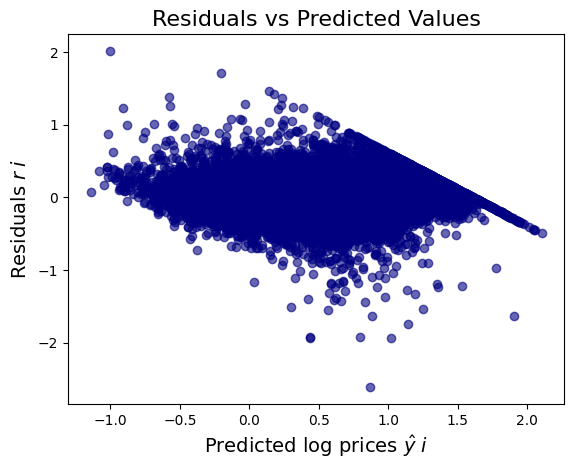

In [81]:
X_incl_const = sm.add_constant(X_train)
model = sm.OLS(y_train,X_incl_const)
results = model.fit()


# Residuals vs Predicted Values

plt.scatter(x = results.fittedvalues,y = results.resid,c='navy',alpha=0.6)


plt.xlabel('Predicted log prices $\hat y_ i$',fontsize=14)
plt.ylabel('Residuals $r_ i$',fontsize=14)
plt.title('Residuals vs Predicted Values',fontsize=16)
plt.show()

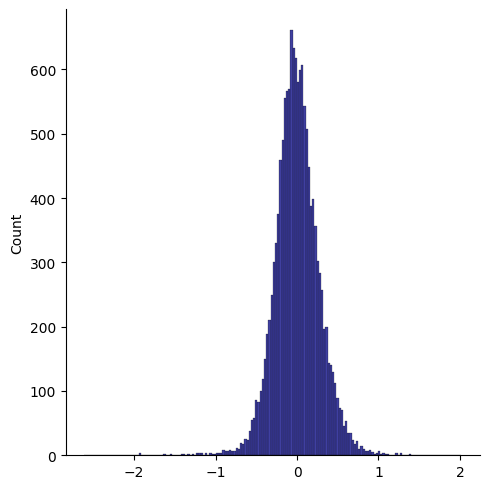

In [ ]:
#distribution of residuals

resid_mean = round(results.resid.mean(),3)
resid_skew = round(results.resid.skew(),3)

sns.displot(results.resid,color="navy")
plt.show()

# Confidence Interval

In [105]:
X_test_with_const = sm.add_constant(X_test)

predictions = results.get_prediction(X_test_with_const)
frame = predictions.summary_frame(alpha=0.05)



frame.to_csv(get_output_path('mLinear/predictions.csv'),index=False)

df_summary = pd.DataFrame({
    'Metric': ['Mean (Среднее)', 'Lower Bound (Мин)', 'Upper Bound (Макс)'],
    'Value': [
        frame['mean'].mean(), 
        frame['obs_ci_lower'].mean(), 
        frame['obs_ci_upper'].mean()
    ]
})
df_summary


,Metric,Value
0,Mean (Среднее),0.589173
1,Lower Bound (Мин),0.048684
2,Upper Bound (Макс),1.129662


# Cross Validation

In [ ]:
model = Pipeline([
    ('preprocessors',preprocessors),
    ('regressor',LinearRegression())
])


scores = cross_val_score(model,X_train,y_train,cv=5,scoring="r2")
print(scores)

[0.59152299 0.59549193 0.5884133  0.60945952 0.61300314]
